In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/tweets-and-user-engagement")

print("Path to dataset files:", path)

import os
import pandas as pd

# List files in the downloaded Kaggle dataset path
print(f"Files in Kaggle dataset directory: {os.listdir(path)}")

# Assuming there's a main CSV file, let's try to load 'tweets.csv'
# This might need adjustment based on the actual file names in the directory.
kaggle_csv_path = os.path.join(path, 'Twitterdatainsheets.csv') # Corrected file name

try:
    kaggle_df = pd.read_csv(kaggle_csv_path)

    print('\nKaggle DataFrame Info:')
    kaggle_df.info()

    print('\nSample from the Kaggle DataFrame:')
    display(kaggle_df.head())

except FileNotFoundError:
    print(f"Error: '{kaggle_csv_path}' not found. Please check the file name in the Kaggle dataset.")
except Exception as e:
    print(f"An error occurred while loading or processing the Kaggle dataset: {e}")

Using Colab cache for faster access to the 'tweets-and-user-engagement' dataset.
Path to dataset files: /kaggle/input/tweets-and-user-engagement
Files in Kaggle dataset directory: ['Twitterdatainsheets.csv', '.nfs000000003432146e00000013']


/tmp/ipykernel_18643/1484622027.py:19: DtypeWarning: Columns (3,4,5,6,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  kaggle_df = pd.read_csv(kaggle_csv_path)



Kaggle DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206295 entries, 0 to 206294
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          206295 non-null  int64  
 1   TweetID        206291 non-null  object 
 2    Weekday       206292 non-null  object 
 3    Hour          106175 non-null  object 
 4    Day           106181 non-null  object 
 5    Lang          106133 non-null  object 
 6    IsReshare     100000 non-null  object 
 7    Reach         100000 non-null  float64
 8    RetweetCount  100000 non-null  float64
 9    Likes         100000 non-null  float64
 10   Klout         100000 non-null  float64
 11   Sentiment     100000 non-null  float64
 12   text          100000 non-null  object 
 13   LocationID    100000 non-null  float64
 14   UserID        100000 non-null  object 
dtypes: float64(6), int64(1), object(8)
memory usage: 23.6+ MB

Sample from the Kaggle DataFrame:


,index,TweetID,Weekday,Hour,Day,Lang,IsReshare,Reach,RetweetCount,Likes,Klout,Sentiment,text,LocationID,UserID
0,0,tw-682712873332805633,Thursday,17,31,en,False,44.0,0.0,0.0,35.0,0.0,We are hiring: Senior Software Engineer - Prot...,3751.0,tw-40932430
1,1,tw-682713045357998080,Thursday,17,31,en,True,1810.0,5.0,0.0,53.0,2.0,RT @CodeMineStatus: This is true Amazon Web Se...,3989.0,tw-3179389829
2,2,tw-682713219375476736,Thursday,17,31,en,False,282.0,0.0,0.0,47.0,0.0,Devops Engineer Aws Ansible Cassandra Mysql Ub...,3741.0,tw-4624808414
3,3,tw-682713436967579648,Thursday,17,31,en,False,2087.0,4.0,0.0,53.0,0.0,Happy New Year to all those AWS instances of o...,3753.0,tw-356447127
4,4,tw-682714048199311366,Thursday,17,31,en,False,953.0,0.0,0.0,47.0,0.0,Amazon is hiring! #Sr. #International Tax Mana...,3751.0,tw-3172686669


Test RMSE (log-engagement): 0.6464
Test R2 (log-engagement): 0.0128


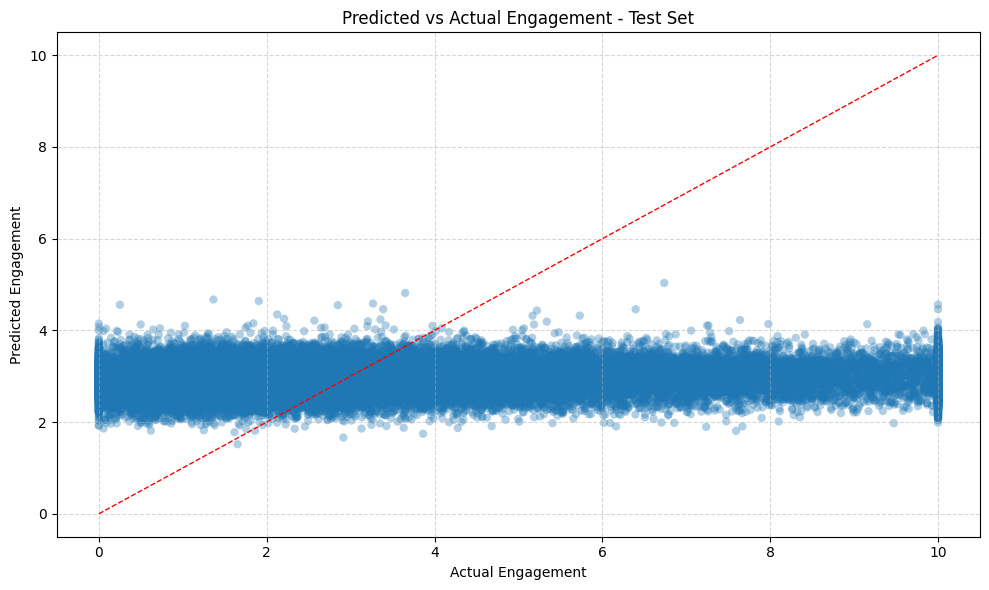

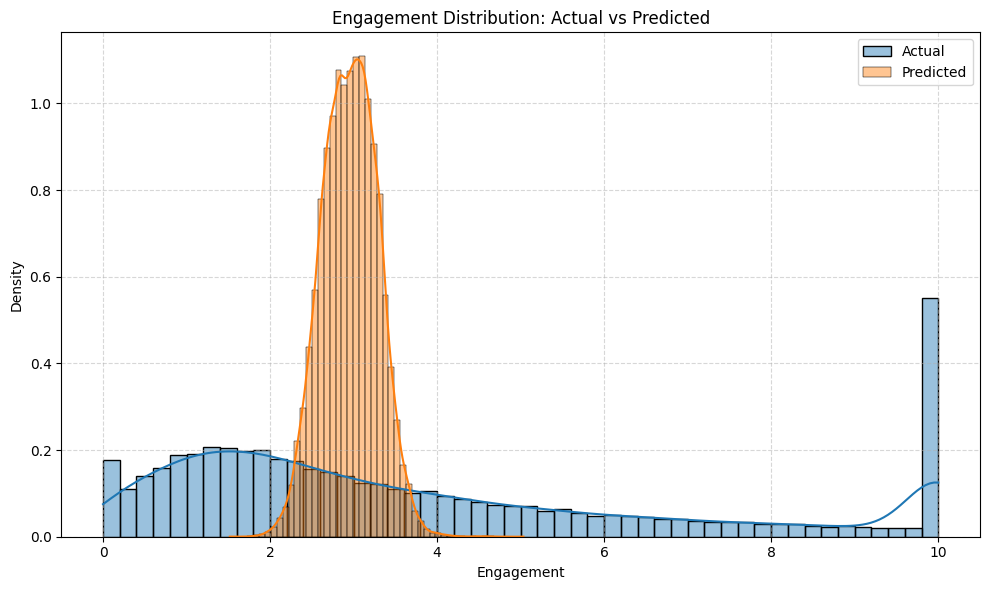

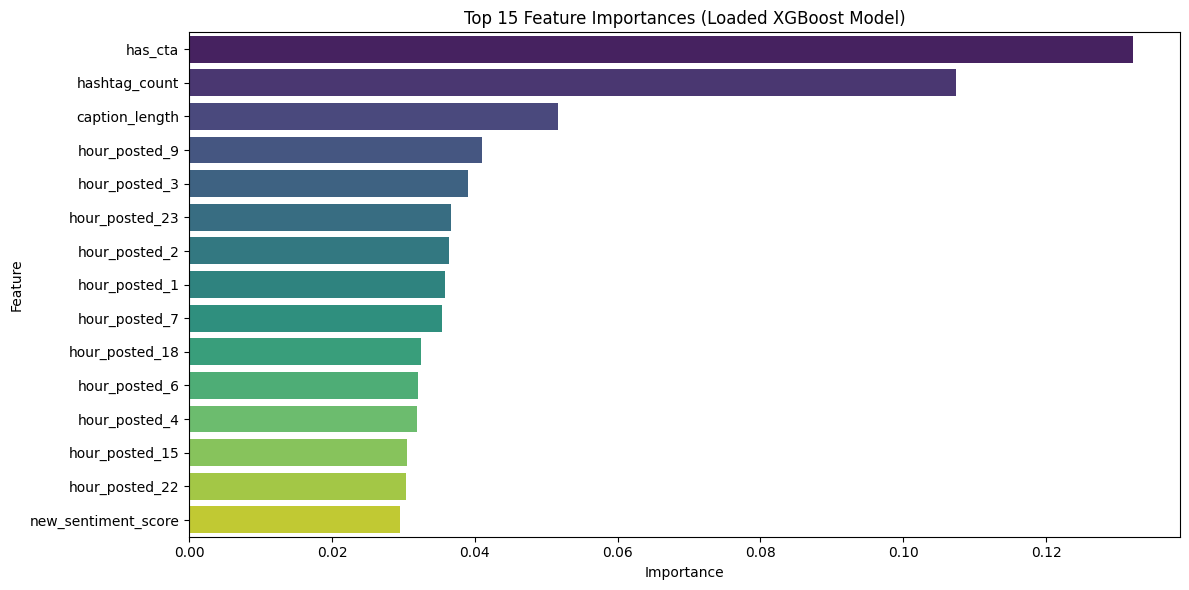

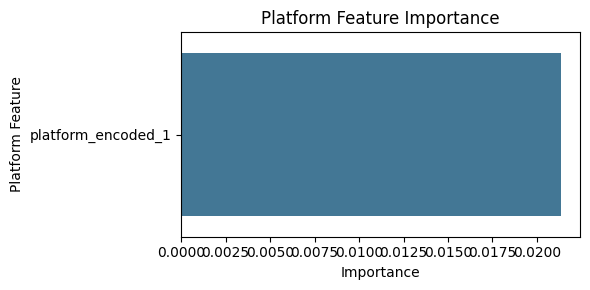

Average actual engagement by predicted engagement decile:
 predicted_decile  actual_engagement  predicted_engagement
                0           3.211693              2.381660
                1           3.529156              2.602208
                2           3.721037              2.719140
                3           3.726638              2.818401
                4           3.836387              2.912436
                5           3.942194              3.005466
                6           4.022377              3.096130
                7           4.125140              3.191152
                8           4.219000              3.303699
                9           4.461488              3.525377


In [5]:
# Synthetic XGBoost Model Validation

#This notebook trains the `synthetic_xgb_model` on a synthetic engagement dataset, performs a chronological test split, and validates the model with presentation-ready charts. The goal is to confirm that high-scoring predictions correspond to higher real engagement in the hold-out test data.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib # Import joblib for loading models and columns

from sklearn.metrics import mean_squared_error, r2_score
## Generate Synthetic Engagement Dataset

#We create a synthetic dataset with features that reflect caption length, hashtag usage, sentiment, CTA presence, platform encoding, and posting hour. A chronological split is simulated by sorting on a generated `timestamp_index`.
n_samples = 200000
np.random.seed(42)

synthetic_df = pd.DataFrame({
    'timestamp_index': np.arange(n_samples),
    'caption_length': np.random.randint(50, 500, size=n_samples),
    'hashtag_count': np.random.randint(0, 10, size=n_samples),
    'new_sentiment_score': np.random.uniform(-0.9, 0.9, size=n_samples),
    'has_cta': np.random.choice([0, 1], size=n_samples, p=[0.5, 0.5]),
    'platform_encoded': np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2]),
    'hour_posted': np.random.randint(0, 24, size=n_samples)
})

engagement_modifier = (
    synthetic_df['caption_length'] * 0.001 +
    synthetic_df['hashtag_count'] * 0.05 +
    synthetic_df['new_sentiment_score'] * 0.12 +
    synthetic_df['has_cta'] * 0.25 +
    (synthetic_df['hour_posted'] % 24) * 0.01
)

base_scores = np.random.lognormal(mean=0.5, sigma=1.0, size=n_samples)
base_scores = np.maximum(0, base_scores + np.random.uniform(-0.5, 0.5, size=n_samples))
synthetic_df['combined_engagement_score'] = np.clip(base_scores * (1 + engagement_modifier), 0, 10)
synthetic_df['log_combined_engagement_score'] = np.log1p(synthetic_df['combined_engagement_score'])

synthetic_df['hour_posted'] = synthetic_df['hour_posted'].astype('category')
synthetic_df['platform_encoded'] = synthetic_df['platform_encoded'].astype('category')

synthetic_df.head()
## Use Pre-trained XGBoost Model with Chronological Split

#We sort by the `timestamp_index` and use the first 80% of samples for training and the final 20% for testing, preserving a chronological ordering.
synthetic_df = synthetic_df.sort_values('timestamp_index').reset_index(drop=True)
split_point = int(len(synthetic_df) * 0.8)

# Define the raw features that will be used for preprocessing
features_for_preprocessing = ['caption_length', 'hashtag_count', 'new_sentiment_score', 'has_cta', 'platform_encoded', 'hour_posted']

# The target variable for the test set
y = synthetic_df['log_combined_engagement_score']
y_test = y.iloc[split_point:]

# Load the pre-trained model and its expected columns
model = joblib.load('/content/xgboost_model.pkl')
model_columns = joblib.load('/content/xgboost_columns.pkl')

# Prepare the test set features
X_test_raw = synthetic_df[features_for_preprocessing].iloc[split_point:]

# Apply one-hot encoding to the test set, similar to how the training data was processed
X_test_processed = pd.get_dummies(X_test_raw, columns=['platform_encoded', 'hour_posted'], drop_first=False) # Changed drop_first to False

# Reindex X_test_processed to ensure column order and presence matches model_columns
# Fill any missing columns with 0 (if the model was trained on more features than currently in test data)
# Drop any extra columns (if test data has new features not in training data)
X_test = X_test_processed.reindex(columns=model_columns, fill_value=0)

y_pred = model.predict(X_test)

rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
r2_val = r2_score(y_test, y_pred)
print(f'Test RMSE (log-engagement): {rmse_val:.4f}')
print(f'Test R2 (log-engagement): {r2_val:.4f}')
## Validation Charts

#The charts below show: predicted vs actual engagement, engagement distribution comparison, and feature importances with platform signals highlighted.
validation_df = pd.DataFrame({
    'actual_log_engagement': y_test,
    'predicted_log_engagement': y_pred
})
validation_df['actual_engagement'] = np.expm1(validation_df['actual_log_engagement'])
validation_df['predicted_engagement'] = np.expm1(validation_df['predicted_log_engagement'])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='actual_engagement',
    y='predicted_engagement',
    data=validation_df,
    alpha=0.35,
    edgecolor='none'
)
max_val = max(validation_df['actual_engagement'].max(), validation_df['predicted_engagement'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1)
plt.title('Predicted vs Actual Engagement - Test Set')
plt.xlabel('Actual Engagement')
plt.ylabel('Predicted Engagement')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(validation_df['actual_engagement'], color='tab:blue', label='Actual', kde=True, stat='density', bins=50, alpha=0.45)
sns.histplot(validation_df['predicted_engagement'], color='tab:orange', label='Predicted', kde=True, stat='density', bins=50, alpha=0.45)
plt.title('Engagement Distribution: Actual vs Predicted')
plt.xlabel('Engagement')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    'Feature': model.feature_names_in_ if hasattr(model, 'feature_names_in_') else model_columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
importance_df['Feature_Type'] = importance_df['Feature'].apply(
    lambda f: 'Platform' if 'platform_encoded' in f else ('Hour' if 'hour_posted' in f else 'Other')
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=importance_df.head(15),
    palette='viridis',
    legend=False
)
plt.title('Top 15 Feature Importances (Loaded XGBoost Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

platform_importance = importance_df[importance_df['Feature_Type'] == 'Platform']
if not platform_importance.empty:
    plt.figure(figsize=(6, 3))
    sns.barplot(
        x='Importance',
        y='Feature',
        hue='Feature',
        data=platform_importance,
        palette='mako',
        legend=False
    )
    plt.title('Platform Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Platform Feature')
    plt.tight_layout()
    plt.show()
else:
    print('Platform-specific feature importance is not available.')

validation_df['predicted_decile'] = pd.qcut(validation_df['predicted_engagement'], 10, labels=False, duplicates='drop')
decile_summary = validation_df.groupby('predicted_decile')[['actual_engagement', 'predicted_engagement']].mean().reset_index()
print('Average actual engagement by predicted engagement decile:')
print(decile_summary.to_string(index=False))


In [8]:
import pickle

def predict_engagement_synthetic(features_dict: dict, model_columns: list) -> float:
    """
    Predicts the engagement score for a given set of post features using the synthetic model.

    Args:
        features_dict (dict): A dictionary containing the following features:
                              'caption_length': int,
                              'hashtag_count': int,
                              'new_sentiment_score': float,
                              'has_cta': int (0 or 1),
                              'platform_encoded': int (0 for Twitter, 1 for LinkedIn, etc. - based on synthetic data),
                              'hour_posted': int (0-23)
        model_columns (list): A list of column names that the model was trained on, in the correct order.

    Returns:
        float: The predicted combined engagement score (inverse log-transformed, non-negative).
    """
    # Convert the input features dictionary to a DataFrame
    input_df = pd.DataFrame([features_dict])

    # Ensure categorical features are of 'category' dtype before one-hot encoding
    input_df['hour_posted'] = input_df['hour_posted'].astype('category')
    input_df['platform_encoded'] = input_df['platform_encoded'].astype('category')

    # One-hot encode categorical features, aligning with the training data (X_train_synthetic)
    # It's crucial that the columns match exactly what the model was trained on.
    # Using drop_first=False to match the validation process for the loaded model.
    processed_input_df = pd.get_dummies(input_df, columns=['platform_encoded', 'hour_posted'], drop_first=False)

    # Reindex to ensure the input DataFrame has the exact same columns and order as the synthetic training data
    # Fill missing columns (if any) with 0, which corresponds to the 'False' in one-hot encoding
    processed_input_df = processed_input_df.reindex(columns=model_columns, fill_value=0)

    # Make prediction using the trained synthetic model
    log_engagement_prediction = model.predict(processed_input_df)[0]

    # Inverse transform the prediction (from log1p back to original scale)
    engagement_score = np.expm1(log_engagement_prediction)

    # Ensure engagement score is non-negative, as engagement cannot be negative
    engagement_score = max(0, engagement_score)

    return engagement_score

# NOTE: The example demonstration code is commented out here to avoid re-running
# during the modification, as it was already run. It can be uncommented for testing.
# Demonstrate the wrapper function with an example
example_features = {
     'caption_length': 150,
     'hashtag_count': 3,
     'new_sentiment_score': 0.75,
     'has_cta': 1,
     'platform_encoded': 0, # Twitter
     'hour_posted': 11 # Changed to 11 AM based on feature importance
}

predicted_score = predict_engagement_synthetic(example_features, model_columns)
print(f"Predicted engagement score for example features (using synthetic model): {predicted_score:.4f}")

# # Save the trained XGBoost model as a .pkl file
# model_filename = 'synthetic_xgb_model.pkl'
# with open(model_filename, 'wb') as file:
#     pickle.dump(synthetic_xgb_model, file)

# print(f"Trained synthetic XGBoost model saved to {model_filename}")

Predicted engagement score for example features (using synthetic model): 2.9682


In [10]:
def find_optimal_posting_hour_synthetic(features_base_dict: dict,model_columns) -> tuple[int, float]:
    """
    Finds the optimal posting hour for a given set of post features using the synthetic model's prediction function.

    Args:
        features_base_dict (dict): A dictionary containing post features
                                   EXCEPT 'hour_posted'. It should include:
                                   'caption_length': int,
                                   'hashtag_count': int,
                                   'new_sentiment_score': float,
                                   'has_cta': int (0 or 1),
                                   'platform_encoded': int (0 for Twitter, 1 for LinkedIn, etc.)

    Returns:
        tuple[int, float]: A tuple containing the optimal hour (0-23) and
                           the predicted engagement score for that hour.
    """
    max_engagement = -1
    optimal_hour = -1

    # Iterate through all possible hours (0 to 23)
    for hour in range(24):
        # Create a full features dictionary for the current hour
        current_features = features_base_dict.copy()
        current_features['hour_posted'] = hour

        # Predict engagement for the current hour using the synthetic predict_engagement function
        predicted_engagement = predict_engagement_synthetic(current_features,model_columns)

        # Check if this hour yields higher engagement
        if predicted_engagement > max_engagement:
            max_engagement = predicted_engagement
            optimal_hour = hour

    return optimal_hour, max_engagement

# Demonstrate the function with an example
example_features_base_synthetic = {
    'caption_length': 150,
    'hashtag_count': 3,
    'new_sentiment_score': 0.75,
    'has_cta': 1,
    'platform_encoded': 0 # Twitter
}

optimal_hour_synthetic, highest_engagement_synthetic = find_optimal_posting_hour_synthetic(example_features_base_synthetic,model_columns)
print(f"For the given features (using synthetic model), the optimal posting hour is {optimal_hour_synthetic}:00 with a predicted engagement of {highest_engagement_synthetic:.4f}")

For the given features (using synthetic model), the optimal posting hour is 23:00 with a predicted engagement of 3.0540


In [14]:
test_hours = synthetic_df['hour_posted'].iloc[split_point:].reset_index(drop=True)
validation_df_with_hours = validation_df.reset_index(drop=True).copy()
validation_df_with_hours['hour_posted'] = test_hours

hourly_engagement_summary = validation_df_with_hours.groupby('hour_posted', observed=False)\
                                             [['actual_engagement', 'predicted_engagement']].mean().reset_index()
hourly_engagement_summary['predicted_engagement_rounded'] = hourly_engagement_summary['predicted_engagement'].round(2)
hourly_engagement_summary['actual_engagement_rounded'] = hourly_engagement_summary['actual_engagement'].round(2)

print('\nAverage Actual vs. Predicted Engagement by Hour Posted:')
display(hourly_engagement_summary[['hour_posted', 'actual_engagement_rounded', 'predicted_engagement_rounded']].sort_values('hour_posted'))


Average Actual vs. Predicted Engagement by Hour Posted:


,hour_posted,actual_engagement_rounded,predicted_engagement_rounded
0,0,3.71,2.91
1,1,3.73,2.86
2,2,3.78,2.86
3,3,3.80,2.86
4,4,3.72,2.86
5,5,3.75,2.90
6,6,3.85,2.88
7,7,3.76,2.90
8,8,3.83,2.92
9,9,4.03,2.91


## Validate Kaggle Model with `kaggle_df_processed.csv`

We will now load `kaggle_df_processed.csv` and use it to validate the `kaggle_xgb_model.pkl`.

In [15]:
import pandas as pd

# Load the processed Kaggle dataset
try:
    kaggle_processed_df = pd.read_csv('/content/kaggle_df_processed.csv')

    print('Kaggle Processed DataFrame Info:')
    kaggle_processed_df.info()

    print('\nSample from the Kaggle Processed DataFrame:')
    display(kaggle_processed_df.head())

except FileNotFoundError:
    print("Error: '/content/kaggle_df_processed.csv' not found. Please ensure the file exists.")
except Exception as e:
    print(f"An error occurred while loading or processing kaggle_df_processed.csv: {e}")

Kaggle Processed DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14533 entries, 0 to 14532
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          14533 non-null  int64  
 1   TweetID                        14533 non-null  object 
 2   day_of_week_posted             14533 non-null  object 
 3   hour_posted                    14533 non-null  int64  
 4   Day                            14533 non-null  int64  
 5   Lang                           14533 non-null  object 
 6   IsReshare                      14533 non-null  bool   
 7   Reach                          14533 non-null  float64
 8   reposts                        14533 non-null  float64
 9   likes                          14533 non-null  float64
 10  Klout                          14533 non-null  float64
 11  Sentiment                      14533 non-null  float64
 12  text         

,index,TweetID,day_of_week_posted,hour_posted,Day,Lang,IsReshare,Reach,reposts,likes,...,LocationID,UserID,combined_engagement_score,log_combined_engagement_score,caption_length,hashtag_count,new_sentiment_score,has_cta,platform_encoded,engagement_category
0,0,tw-682712873332805633,Thursday,17,31,en,False,44.0,0.0,0.0,...,3751.0,tw-40932430,0.000004,0.000004,242.0,0.0,0.0000,0.0,0.0,Non-Zero
1,1,tw-682713045357998080,Thursday,17,31,en,True,1810.0,5.0,0.0,...,3989.0,tw-3179389829,0.000366,0.000366,137.0,0.0,0.5423,0.0,0.0,Non-Zero
2,2,tw-682713219375476736,Thursday,17,31,en,False,282.0,0.0,0.0,...,3741.0,tw-4624808414,0.000027,0.000027,222.0,0.0,0.4995,0.0,0.0,Non-Zero
3,3,tw-682713436967579648,Thursday,17,31,en,False,2087.0,4.0,0.0,...,3753.0,tw-356447127,0.000355,0.000355,50.0,0.0,0.6114,0.0,0.0,Non-Zero
4,4,tw-682714048199311366,Thursday,17,31,en,False,953.0,0.0,0.0,...,3751.0,tw-3172686669,0.000092,0.000092,303.0,0.0,0.3147,0.0,0.0,Non-Zero


Kaggle Model Test RMSE (real data): 0.0139
Kaggle Model Test R2 (real data): 0.5889


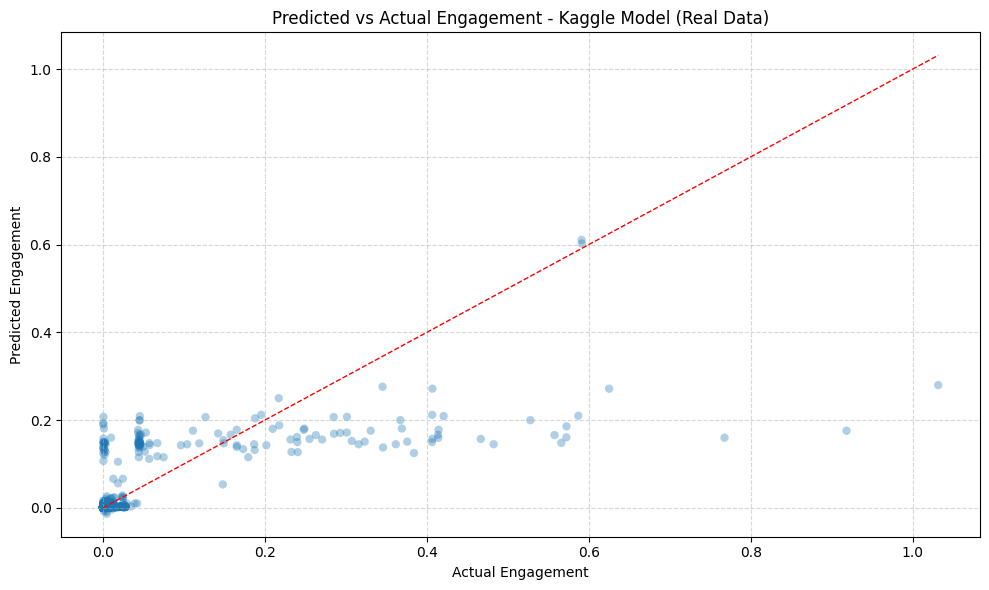

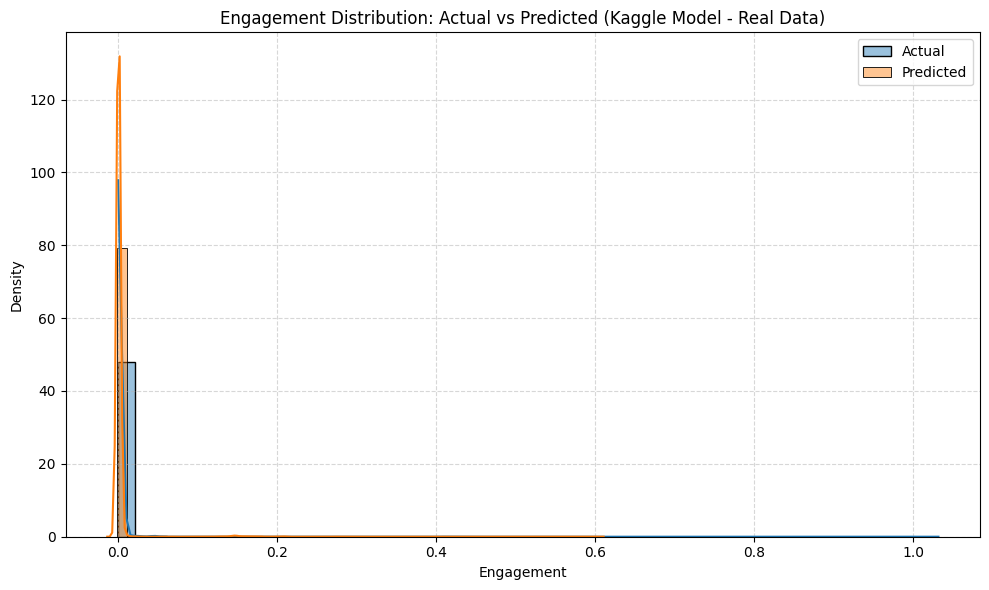

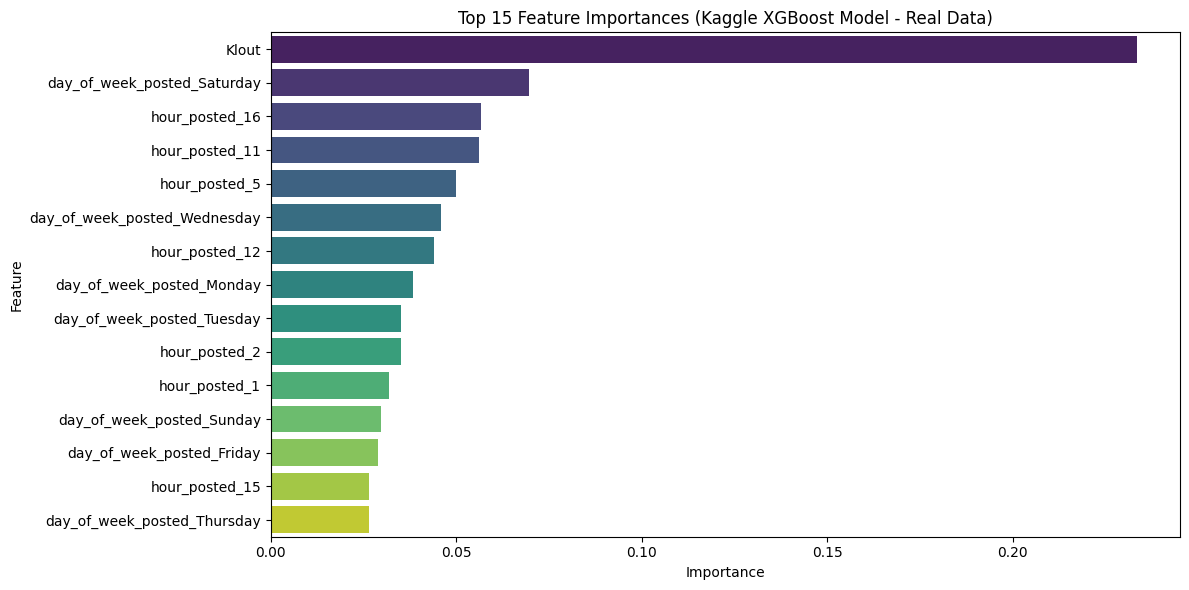

Platform-specific feature importance is not available for Kaggle Model (Real Data).
Average actual engagement by predicted engagement decile (Kaggle Model - Real Data):
 predicted_decile  actual_engagement  predicted_engagement
                0           0.000257              0.000273
                1           0.000311              0.000393
                2           0.000478              0.000406
                3           0.000292              0.000425
                4           0.000338              0.000459
                5           0.000360              0.000493
                6           0.000458              0.000585
                7           0.000498              0.000656
                8           0.019650              0.017733


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Import joblib for loading models and columns
from sklearn.metrics import mean_squared_error, r2_score

# Filter kaggle_processed_df for non-null values in target and key features
kaggle_processed_df_cleaned = kaggle_processed_df.dropna(subset=[
    'log_combined_engagement_score', 'caption_length', 'hashtag_count',
    'new_sentiment_score', 'has_cta', 'platform_encoded', 'Klout', 'Sentiment',
    'day_of_week_posted', 'Lang', 'IsReshare', 'hour_posted'
]).copy().reset_index(drop=True)

# Define target variable
y_real = kaggle_processed_df_cleaned['log_combined_engagement_score']

# Load the pre-trained Kaggle model and its expected columns
model_kaggle = joblib.load('/content/kaggle_xgb_model.pkl')
model_columns_kaggle = joblib.load('/content/kaggle_xgboost_columns.pkl')

# Select features from the cleaned DataFrame, excluding target and irrelevant IDs/text
X_raw_kaggle_real = kaggle_processed_df_cleaned.drop(columns=[
    'log_combined_engagement_score', 'combined_engagement_score', 'index',
    'TweetID', 'Day', 'LocationID', 'UserID', 'text', 'engagement_category'
])

# Convert appropriate columns to category type for one-hot encoding
X_raw_kaggle_real['hour_posted'] = X_raw_kaggle_real['hour_posted'].astype('category')
X_raw_kaggle_real['platform_encoded'] = X_raw_kaggle_real['platform_encoded'].astype('category')

# One-hot encode categorical features
# Use drop_first=False to ensure all dummy variables are created, consistent with previous steps.
X_processed_kaggle_real = pd.get_dummies(X_raw_kaggle_real, columns=[
    'day_of_week_posted', 'Lang', 'hour_posted', 'platform_encoded'
], drop_first=False)

# Align columns with the model's expected columns
X_kaggle_final = X_processed_kaggle_real.reindex(columns=model_columns_kaggle, fill_value=0)

# --- Optional: Verify column alignment (for debugging) ---
missing_in_X = set(model_columns_kaggle) - set(X_kaggle_final.columns)
extra_in_X = set(X_kaggle_final.columns) - set(model_columns_kaggle)

if missing_in_X:
    print(f"Warning: Columns in model_columns_kaggle not found in X_kaggle_final: {missing_in_X}")
if extra_in_X:
    print(f"Warning: Columns in X_kaggle_final not found in model_columns_kaggle: {extra_in_X}")
# --------------------------------------------------------

# Make predictions
y_pred_kaggle_real = model_kaggle.predict(X_kaggle_final)

# Calculate metrics
rmse_val_kaggle_real = np.sqrt(mean_squared_error(y_real, y_pred_kaggle_real))
r2_val_kaggle_real = r2_score(y_real, y_pred_kaggle_real)
print(f'Kaggle Model Test RMSE (real data): {rmse_val_kaggle_real:.4f}')
print(f'Kaggle Model Test R2 (real data): {r2_val_kaggle_real:.4f}')

# Create validation_df for charts
validation_df_kaggle_real = pd.DataFrame({
    'actual_log_engagement': y_real,
    'predicted_log_engagement': y_pred_kaggle_real
})
validation_df_kaggle_real['actual_engagement'] = np.expm1(validation_df_kaggle_real['actual_log_engagement'])
validation_df_kaggle_real['predicted_engagement'] = np.expm1(validation_df_kaggle_real['predicted_log_engagement'])

# --- Validation Charts ---

# Predicted vs Actual Engagement
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='actual_engagement',
    y='predicted_engagement',
    data=validation_df_kaggle_real,
    alpha=0.35,
    edgecolor='none'
)
max_val_kaggle_real = max(validation_df_kaggle_real['actual_engagement'].max(), validation_df_kaggle_real['predicted_engagement'].max())
plt.plot([0, max_val_kaggle_real], [0, max_val_kaggle_real], color='red', linestyle='--', linewidth=1)
plt.title('Predicted vs Actual Engagement - Kaggle Model (Real Data)')
plt.xlabel('Actual Engagement')
plt.ylabel('Predicted Engagement')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Engagement Distribution
plt.figure(figsize=(10, 6))
sns.histplot(validation_df_kaggle_real['actual_engagement'], color='tab:blue', label='Actual', kde=True, stat='density', bins=50, alpha=0.45)
sns.histplot(validation_df_kaggle_real['predicted_engagement'], color='tab:orange', label='Predicted', kde=True, stat='density', bins=50, alpha=0.45)
plt.title('Engagement Distribution: Actual vs Predicted (Kaggle Model - Real Data)')
plt.xlabel('Engagement')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Feature Importances
importance_df_kaggle_real = pd.DataFrame({
    'Feature': model_kaggle.feature_names_in_ if hasattr(model_kaggle, 'feature_names_in_') else model_columns_kaggle,
    'Importance': model_kaggle.feature_importances_
}).sort_values('Importance', ascending=False)
importance_df_kaggle_real['Feature_Type'] = importance_df_kaggle_real['Feature'].apply(
    lambda f: 'Platform' if 'platform_encoded' in f else ('Hour' if 'hour_posted' in f else 'Weekday' if 'day_of_week_posted' in f else 'Language' if 'Lang_' in f else 'Other')
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature', # Added for consistency with previous plotting fix
    data=importance_df_kaggle_real.head(15),
    palette='viridis',
    legend=False
)
plt.title('Top 15 Feature Importances (Kaggle XGBoost Model - Real Data)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Platform-specific feature importance
platform_importance_kaggle_real = importance_df_kaggle_real[importance_df_kaggle_real['Feature_Type'] == 'Platform']
if not platform_importance_kaggle_real.empty:
    plt.figure(figsize=(6, 3))
    sns.barplot(
        x='Importance',
        y='Feature',
        hue='Feature', # Added for consistency
        data=platform_importance_kaggle_real,
        palette='mako',
        legend=False
    )
    plt.title('Platform Feature Importance (Kaggle Model - Real Data)')
    plt.xlabel('Importance')
    plt.ylabel('Platform Feature')
    plt.tight_layout()
    plt.show()
else:
    print('Platform-specific feature importance is not available for Kaggle Model (Real Data).')

# Decile Summary
validation_df_kaggle_real['predicted_decile'] = pd.qcut(validation_df_kaggle_real['predicted_engagement'], 10, labels=False, duplicates='drop')
decile_summary_kaggle_real = validation_df_kaggle_real.groupby('predicted_decile', observed=False)[['actual_engagement', 'predicted_engagement']].mean().reset_index()
print('Average actual engagement by predicted engagement decile (Kaggle Model - Real Data):')
print(decile_summary_kaggle_real.to_string(index=False))